In [1]:
import os
import sys
import gc
import yaml
import torch
import joblib
import numpy as np
import pandas as pd
import awkward as ak
import matplotlib.pyplot as plt
from tqdm import tqdm

# --- Path Configurations ---
helpers_path = os.path.join('/home/aegis/Titan1/NRAD/data/model_scripts')
sys.path.insert(0, os.path.abspath(helpers_path))
from Classifier import Classifier
from SimpleMAF import SimpleMAF

base_data_path = "/home/aegis/Titan1/NRAD/data"
model_path = os.path.join(base_data_path, "Models_Final")
config_path = os.path.join(base_data_path, "configs")
eval_dir = "CWoLa_CR_Final"

# Train Paths
MC_train_outdir_CR = os.path.join(base_data_path, "Scaled_RegDiff/CR/mc_train")
Data_train_outdir_CR = os.path.join(base_data_path, "Scaled_RegDiff/CR/data_train")

# Test Paths
MC_test_outdir_CR = os.path.join(base_data_path, "Scaled_RegDiff/CR/mc_test")
Data_test_outdir_CR = os.path.join(base_data_path, "Scaled_RegDiff/CR/data_test")

# --- Global ML Configurations ---
CR_regions = ["CR_emu", "CR0L", "CR1ele", "CR1eleb", "CR1mu", "CR1mub", "CR2ele", "CR2mu"]
context_var = ['ht', 'met_recalc_pt']
features = ['mjj', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32']
features_to_log = ['mjj']

print("Setting up device...")
CUDA = False
print("CUDA available:", CUDA)
device = torch.device("cuda" if CUDA else "cpu")

/home/aegis/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Setting up device...
CUDA available: False


In [2]:
def regularize_weights(w_arr, sigma=3.0):
    """
    Caps extreme weights at a maximum threshold instead of setting them to 0,
    preserving the statistical yield of the background estimation.
    """
    mean_w = np.mean(w_arr)
    std_w = np.std(w_arr)
    threshold = mean_w + (sigma * std_w)
    return np.clip(w_arr, a_min=0, a_max=threshold)

def plot_stacked_crs_vs_data(
    mc_events_dict, data_events_dict, mc_weights_dict, regions, 
    feature_names, log_features=None, save_dir=None, bins=50, 
    val_range=(-3.0, 3.0), ratio_ylim=(0.5, 1.5), normalize_mc_to_data=True
):
    """Plots Total Data vs Stacked MC with stat uncertainty and ratio panel."""
    if log_features is None: log_features = []
    if save_dir and not os.path.exists(save_dir): os.makedirs(save_dir)

    feature_labels = {
        'mjj': r"$m_{jj}$",
        'ljet1_tau21': r"Jet 1 $\tau_{21}$",
        'ljet1_tau32': r"Jet 1 $\tau_{32}$",
        'ljet2_tau21': r"Jet 2 $\tau_{21}$",
        'ljet2_tau32': r"Jet 2 $\tau_{32}$",
    }
    colors = plt.cm.tab10.colors

    for feature in feature_names:
        display_label = feature_labels.get(feature, feature)
        
        mc_vals_list, mc_weights_list, data_vals_list, valid_regions = [], [], [], []
        
        for region in regions:
            # Note: Expecting dictionaries of Pandas DataFrames here
            if feature in mc_events_dict[region].columns and feature in data_events_dict[region].columns:
                mc_vals_list.append(mc_events_dict[region][feature].values)
                mc_weights_list.append(mc_weights_dict[region] if isinstance(mc_weights_dict[region], np.ndarray) else mc_weights_dict[region].values)
                data_vals_list.append(data_events_dict[region][feature].values)
                valid_regions.append(region)
                
        if not mc_vals_list: continue
            
        all_mc_vals = np.concatenate(mc_vals_list)
        all_data_vals = np.concatenate(data_vals_list)
        raw_mc_weights = np.concatenate(mc_weights_list)

        if normalize_mc_to_data:
            scale_factor = len(all_data_vals) / np.sum(raw_mc_weights)
            mc_weights_list = [w * scale_factor for w in mc_weights_list]
            all_mc_weights = raw_mc_weights * scale_factor
        else:
            all_mc_weights = raw_mc_weights
        
        counts_data, bin_edges = np.histogram(all_data_vals, bins=bins, range=val_range)
        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
        err_data = np.sqrt(counts_data)
        
        counts_mc, _ = np.histogram(all_mc_vals, bins=bin_edges, weights=all_mc_weights)
        var_mc, _ = np.histogram(all_mc_vals, bins=bin_edges, weights=all_mc_weights**2)
        err_mc = np.sqrt(var_mc)

        fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(10, 10), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)
        plt.subplots_adjust(hspace=0.05) 

        # Main Panel
        ax1.hist(mc_vals_list, bins=bin_edges, weights=mc_weights_list, histtype='stepfilled', stacked=True, label=valid_regions, edgecolor='black', linewidth=0.5, alpha=0.9, color=colors[:len(valid_regions)])
        ax1.bar(x=bin_centers, height=2 * err_mc, bottom=counts_mc - err_mc, width=np.diff(bin_edges), fill=False, hatch='////', edgecolor='dimgray', linewidth=0, alpha=0.5, label='MC Stat. Unc.', zorder=4)
        ax1.errorbar(bin_centers, counts_data, yerr=err_data, fmt='ko', label='Total Data', zorder=5)

        ax1.set_ylabel("Events / Bin", fontsize=12)
        ax1.legend(loc='best', frameon=False, fontsize=11, ncol=2)
        
        max_y = max(np.max(counts_data), np.max(counts_mc + err_mc))
        if feature in log_features:
            ax1.set_yscale('log')
            ax1.set_ylim(0.1, max_y * 50) 
        else:
            ax1.set_ylim(0, max_y * 1.3)

        # Ratio Panel
        valid_mask = counts_data > 0
        safe_data = np.where(valid_mask, counts_data, 1e-10)
        rel_err_data = err_data / safe_data
        rel_err_data[~valid_mask] = 0 
        
        ax2.fill_between(bin_edges, np.append(1 - rel_err_data, 1 - rel_err_data[-1]), np.append(1 + rel_err_data, 1 + rel_err_data[-1]), step='post', color='gray', alpha=0.3, label='Data Stat. Unc.', zorder=1)
        ax2.axhline(1.0, color='black', linestyle='--', zorder=2)
        
        ratio = counts_mc / safe_data
        ratio_err = err_mc / safe_data 
        ratio_plot = np.where(valid_mask, ratio, np.nan)
        
        ax2.step(bin_edges, np.append(ratio_plot, ratio_plot[-1]), where='post', linewidth=1.5, color='tab:red', alpha=0.8, label="MC / Data")
        ax2.errorbar(bin_centers[valid_mask], ratio_plot[valid_mask], yerr=ratio_err[valid_mask], fmt='none', ecolor='tab:red', alpha=0.5)

        ax2.set_xlabel(display_label, fontsize=12)
        ax2.set_ylabel("MC / Data", fontsize=12)
        ax2.set_ylim(ratio_ylim) 
        
        if save_dir:
            plt.savefig(os.path.join(save_dir, f"{feature}_stacked.png"), bbox_inches='tight', dpi=300)
        
        plt.show()
        plt.close()

In [3]:
# print("--- LOADING AND PREPARING DATA FOR TRAINING ---")
# all_x_train, all_y_train, all_weights = [], [], []
# cr0l_x_train, cr0l_y_train, cr0l_weights = None, None, None

# for region in CR_regions:
#     print("Loading data for region:", region)
#     df_mc = pd.read_parquet(os.path.join(MC_train_outdir_CR, f"{region}_train.parquet"))
#     df_data = pd.read_parquet(os.path.join(Data_train_outdir_CR, f"{region}_train.parquet"))

#     n_data, n_mc = len(df_data), len(df_mc)
    
#     # Extract arrays
#     data_cr_train = df_data[context_var + features].values
#     mc_cr_train = df_mc[context_var + features].values
#     input_x = np.concatenate([data_cr_train, mc_cr_train], axis=0)
    
#     data_cr_labels = np.ones(n_data).reshape(-1, 1)
#     mc_cr_labels = np.zeros(n_mc).reshape(-1, 1)
#     input_y = np.concatenate([data_cr_labels, mc_cr_labels], axis=0)

#     # Normalize weights globally per region
#     sum_mc_weight = df_mc['weight_phys'].sum()
#     global_scale = n_data / sum_mc_weight
    
#     data_weights = np.ones(n_data)
#     mc_weights = df_mc['weight_phys'].values * global_scale
#     input_w = np.concatenate([data_weights, mc_weights], axis=0).reshape(-1, 1)

#     all_x_train.append(input_x)
#     all_y_train.append(input_y)
#     all_weights.append(input_w)

#     if region == "CR0L":
#         cr0l_x_train, cr0l_y_train, cr0l_weights = input_x, input_y, input_w

#     # Aggressive memory cleanup
#     del df_mc, df_data, data_cr_train, mc_cr_train, data_cr_labels, mc_cr_labels, data_weights, mc_weights
#     gc.collect()

# input_x_train_ALL = np.concatenate(all_x_train, axis=0)
# input_y_train_ALL = np.concatenate(all_y_train, axis=0)
# input_weights_ALL = np.concatenate(all_weights, axis=0)

# # Free up the lists now that we have the master arrays
# del all_x_train, all_y_train, all_weights
# gc.collect()

# print(f"Phase 1 Combined Training Data Shape: {input_x_train_ALL.shape}")

In [6]:
import os
import gc
import numpy as np
import pandas as pd

print("--- LOADING AND PREPARING DATA FOR STAGE 1 & 2 TRAINING ---")

# Accumulators for Stage 1
all_reweight_x, all_reweight_y, all_reweight_w = [], [], []
all_generate_x = [] # Will now store pandas DataFrames

# Placeholders for Stage 2
reweight_x_stage2, reweight_y_stage2, reweight_w_stage2 = None, None, None
generate_x_stage2 = None # Will store a pandas DataFrame

for region in CR_regions:
    print(f"Loading data for region: {region}")
    df_mc = pd.read_parquet(os.path.join(MC_train_outdir_CR, f"{region}_train.parquet"))
    df_data = pd.read_parquet(os.path.join(Data_train_outdir_CR, f"{region}_train.parquet"))

    n_data, n_mc = len(df_data), len(df_mc)
    
    # 1. Keep as DataFrame for the Generate Model
    data_cr_train_df = df_data[context_var + features]
    all_generate_x.append(data_cr_train_df)
    
    # 2. Extract numpy arrays for the Reweight Model
    data_cr_train = data_cr_train_df.values
    mc_cr_train = df_mc[context_var + features].values
    
    # --- PREPARE REWEIGHT DATA (Data + MC) ---
    input_x = np.concatenate([data_cr_train, mc_cr_train], axis=0)
    
    data_cr_labels = np.ones(n_data).reshape(-1, 1)
    mc_cr_labels = np.zeros(n_mc).reshape(-1, 1)
    input_y = np.concatenate([data_cr_labels, mc_cr_labels], axis=0)

    # Normalize weights globally per region
    sum_mc_weight = df_mc['weight_phys'].sum()
    global_scale = n_data / sum_mc_weight
    
    data_weights = np.ones(n_data)
    mc_weights = df_mc['weight_phys'].values * global_scale
    input_w = np.concatenate([data_weights, mc_weights], axis=0).reshape(-1, 1)

    # Accumulate for Stage 1
    all_reweight_x.append(input_x)
    all_reweight_y.append(input_y)
    all_reweight_w.append(input_w)

    # --- ISOLATE STAGE 2 DATA (CR0L Only) ---
    if region == "CR0L":
        reweight_x_stage2 = input_x.copy()
        reweight_y_stage2 = input_y.copy()
        reweight_w_stage2 = input_w.copy()
        
        # .copy() ensures the DataFrame is isolated for fine-tuning
        generate_x_stage2 = data_cr_train_df.copy() 
        print("  -> Captured isolated CR0L data for Stage 2.")

    # Aggressive memory cleanup
    del df_mc, df_data, data_cr_train_df, mc_cr_train, data_cr_labels, mc_cr_labels, data_weights, mc_weights
    gc.collect()

# --- FINALIZE STAGE 1 ARRAYS ---
print("Concatenating Stage 1 data...")
reweight_x_stage1 = np.concatenate(all_reweight_x, axis=0)
reweight_y_stage1 = np.concatenate(all_reweight_y, axis=0)
reweight_w_stage1 = np.concatenate(all_reweight_w, axis=0)

# Use pd.concat for DataFrames
generate_x_stage1 = pd.concat(all_generate_x, axis=0, ignore_index=True)

# Free up accumulators
del all_reweight_x, all_reweight_y, all_reweight_w, all_generate_x
gc.collect()

# --- SUMMARY ---
print("\n--- DATA PREPARATION COMPLETE ---")
print(f"STAGE 1 (All Regions):")
print(f"  Reweight Model - X: {reweight_x_stage1.shape}, Y: {reweight_y_stage1.shape}, W: {reweight_w_stage1.shape}")
print(f"  Generate Model - DataFrame Shape: {generate_x_stage1.shape}")

print(f"\nSTAGE 2 (CR0L Only):")
print(f"  Reweight Model - X: {reweight_x_stage2.shape}, Y: {reweight_y_stage2.shape}, W: {reweight_w_stage2.shape}")
print(f"  Generate Model - DataFrame Shape: {generate_x_stage2.shape}")

--- LOADING AND PREPARING DATA FOR STAGE 1 & 2 TRAINING ---
Loading data for region: CR_emu
Loading data for region: CR0L
  -> Captured isolated CR0L data for Stage 2.
Loading data for region: CR1ele
Loading data for region: CR1eleb
Loading data for region: CR1mu
Loading data for region: CR1mub
Loading data for region: CR2ele
Loading data for region: CR2mu
Concatenating Stage 1 data...

--- DATA PREPARATION COMPLETE ---
STAGE 1 (All Regions):
  Reweight Model - X: (43876714, 7), Y: (43876714, 1), W: (43876714, 1)
  Generate Model - DataFrame Shape: (39595626, 7)

STAGE 2 (CR0L Only):
  Reweight Model - X: (41468038, 7), Y: (41468038, 1), W: (41468038, 1)
  Generate Model - DataFrame Shape: (38231202, 7)


### Reweight

In [5]:
with open(f"{config_path}/reweight_physics.yml", 'r') as stream:
    params_rw = yaml.safe_load(stream)

print("\n--- STAGE 1: Pre-training on ALL Control Regions ---")
NN_rw = Classifier(
    n_inputs=(len(context_var) + len(features)), 
    layers=params_rw["layers"], 
    learning_rate=params_rw["learning_rate"], 
    device=device,
)

# Train on all combined regions
NN_rw.train(
    input_x=reweight_x_stage1, 
    input_y=reweight_y_stage1, 
    # weights=reweight_w_stage1,
    save_model=True, 
    batch_size=params_rw["batch_size"], 
    n_epochs=params_rw["n_epochs"], 
    model_name="reweight_PreTrained_3x100", 
    outdir=model_path
)

print("\n--- STAGE 2: Fine-Tuning exclusively on CR0L ---")
fine_tune_lr = params_rw["learning_rate"] / 10.0
for param_group in NN_rw.optimizer.param_groups:
    param_group['lr'] = fine_tune_lr
print(f"Reduced learning rate to {fine_tune_lr}")

NN_rw.train(
    input_x=reweight_x_stage2, 
    input_y=reweight_y_stage2, 
    weights=reweight_w_stage2, 
    save_model=True, 
    batch_size=params_rw["batch_size"], 
    n_epochs=params_rw["n_epochs"] // 2, 
    model_name="reweight_CR0L_FineTuned_3x500", 
    outdir=model_path
)
print("Finished Transfer Learning for Reweight Model!")


--- STAGE 1: Pre-training on ALL Control Regions ---


  0%|          | 0/50 [01:06<?, ?it/s]


KeyboardInterrupt: 

### Generate

In [ ]:
# 1. Slice using pandas column names and extract underlying numpy arrays
# Stage 1 (All Regions)
generate_context_stage1 = generate_x_stage1[context_var].values
generate_features_stage1 = generate_x_stage1[features].values

# Stage 2 (CR0L Only)
generate_context_stage2 = generate_x_stage2[context_var].values
generate_features_stage2 = generate_x_stage2[features].values

print(f"STAGE 1 Generative Training - Features Shape: {generate_features_stage1.shape}, Context Shape: {generate_context_stage1.shape}")
print(f"STAGE 2 Generative Training - Features Shape: {generate_features_stage2.shape}, Context Shape: {generate_context_stage2.shape}")

with open(f"{config_path}/generate_physics.yml", 'r') as stream:
    params = yaml.safe_load(stream)

print("\n--- STAGE 1: Pre-training Normalizing Flow on ALL Control Regions ---")
MAF = SimpleMAF(
    num_features=len(features), 
    num_context=len(context_var), 
    device=device, 
    num_layers=params["n_layers"], 
    num_hidden_features=params["n_hidden_features"], 
    learning_rate=params["learning_rate"]
)

MAF.train(
    data=generate_features_stage1, 
    cond=generate_context_stage1, 
    batch_size=params["batch_size"], 
    n_epochs=params["n_epochs"], 
    outdir=model_path, 
    save_model=True, 
    model_name="generate_PreTrained_cpu"
)

print("\n--- STAGE 2: Fine-Tuning Normalizing Flow exclusively on CR0L ---")
# Drop the learning rate by a factor of 10 for fine-tuning
fine_tune_lr = params["learning_rate"] / 10.0
for param_group in MAF.optimizer.param_groups:
    param_group['lr'] = fine_tune_lr
print(f"Reduced learning rate to {fine_tune_lr}")

MAF.train(
    data=generate_features_stage2, 
    cond=generate_context_stage2, 
    batch_size=params["batch_size"], 
    n_epochs=params["n_epochs"] // 2, 
    outdir=model_path, 
    save_model=True, 
    model_name="generate_CR0L_FineTuned_cpu"
)
print("Finished Transfer Learning for Generate Model!")

STAGE 1 Generative Training - Features Shape: (39595626, 5), Context Shape: (39595626, 2)
STAGE 2 Generative Training - Features Shape: (38231202, 5), Context Shape: (38231202, 2)

--- STAGE 1: Pre-training Normalizing Flow on ALL Control Regions ---


 40%|====      | 8/20 [6:04:29<9:06:44, 2733.68s/it]



--- STAGE 2: Fine-Tuning Normalizing Flow exclusively on CR0L ---
Reduced learning rate to 0.0001


 10%|=         | 1/10 [46:38<6:59:48, 2798.75s/it]


--- EVALUATING REWEIGHT CLASSIFIER IN CR0L ---
Generating samples...


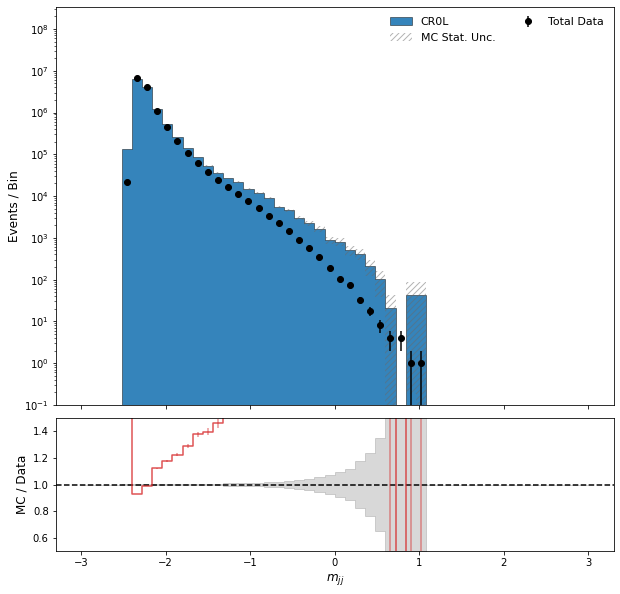

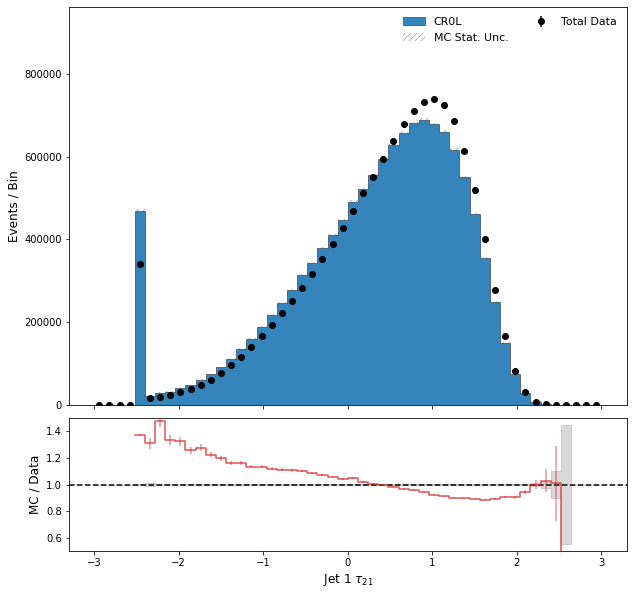

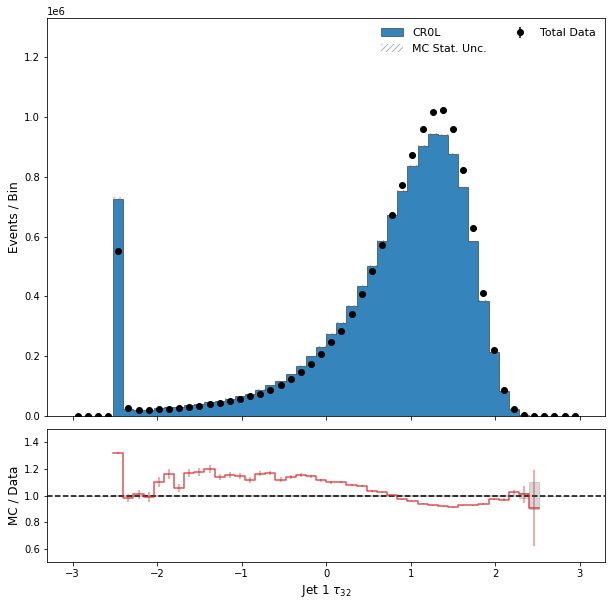

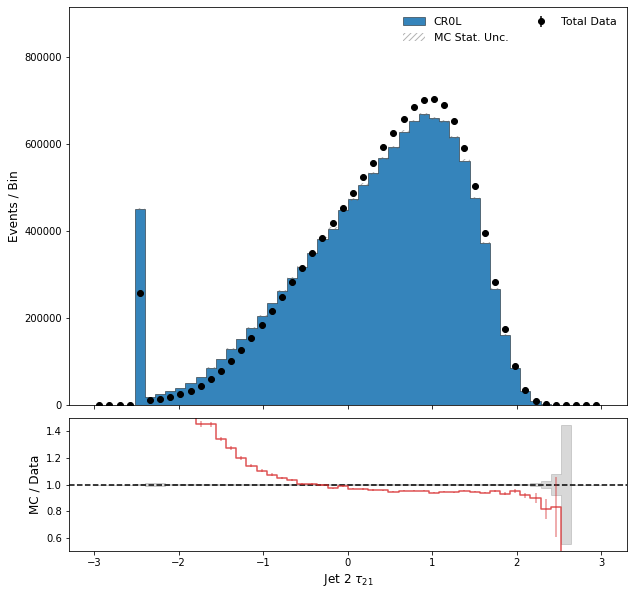

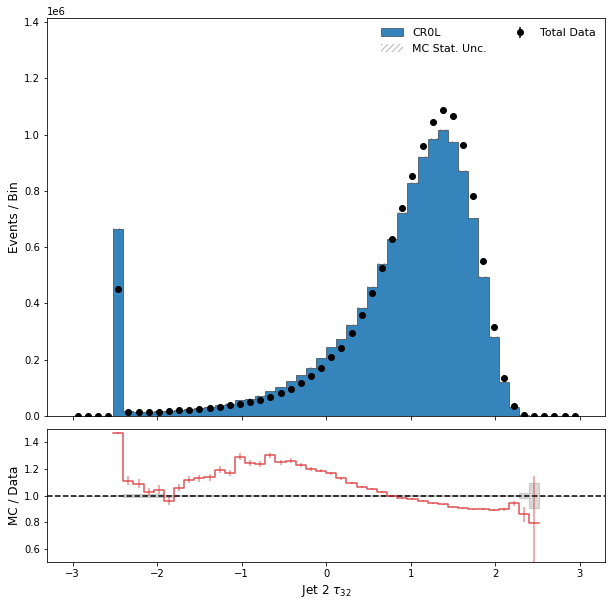

In [ ]:
print("\n--- EVALUATING REWEIGHT CLASSIFIER IN CR0L ---")
MC_events_test, Data_events_test, weights_reweight = {}, {}, {}

# Load CR0L Test Events
df_mc_test = pd.read_parquet(os.path.join(MC_test_outdir_CR, "CR0L_test.parquet"))
df_data_test = pd.read_parquet(os.path.join(Data_test_outdir_CR, "CR0L_test.parquet"))

MC_events_test["CR0L"] = df_mc_test
Data_events_test["CR0L"] = df_data_test

# Load Model
model_path_region = os.path.join(model_path, "reweight_CR0L_FineTuned_3x500.pt")
NN_reweight = torch.load(model_path_region, weights_only=False)
NN_reweight.to(device)

print("Generating samples...")
input_data = df_mc_test[context_var + features].values
w_prob = NN_reweight.evaluation(input_data)

# CRITICAL FIX: Clip probabilities to prevent Divide-By-Zero / NaN errors
w_prob = np.clip(w_prob, 1e-7, 1.0 - 1e-7)
w_cr = (w_prob / (1 - w_prob)).flatten()

# CRITICAL FIX: Cap outliers using standard deviation instead of deleting them
w_cr = regularize_weights(w_cr, sigma=3.0)

weights_reweight["CR0L"] = w_cr * (len(df_data_test) / len(df_mc_test))

plot_stacked_crs_vs_data(
    mc_events_dict=MC_events_test, data_events_dict=Data_events_test,
    mc_weights_dict=weights_reweight, regions=["CR0L"],
    feature_names=features, log_features=features_to_log,
    # save_dir=f"{eval_dir}/publication_plots_stacked",
    normalize_mc_to_data=True
)


--- EVALUATING REWEIGHT CLASSIFIER IN SIGNAL REGION ---


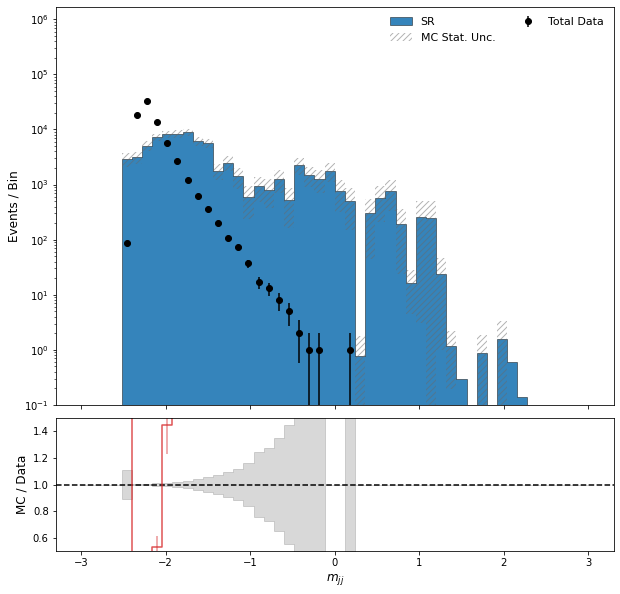

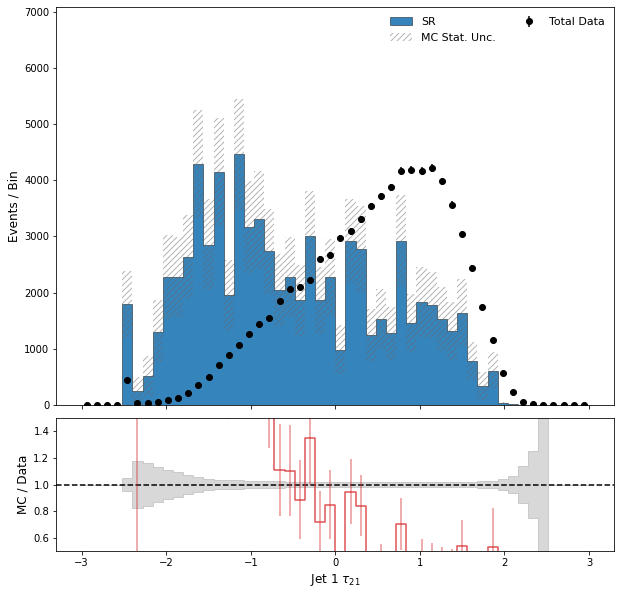

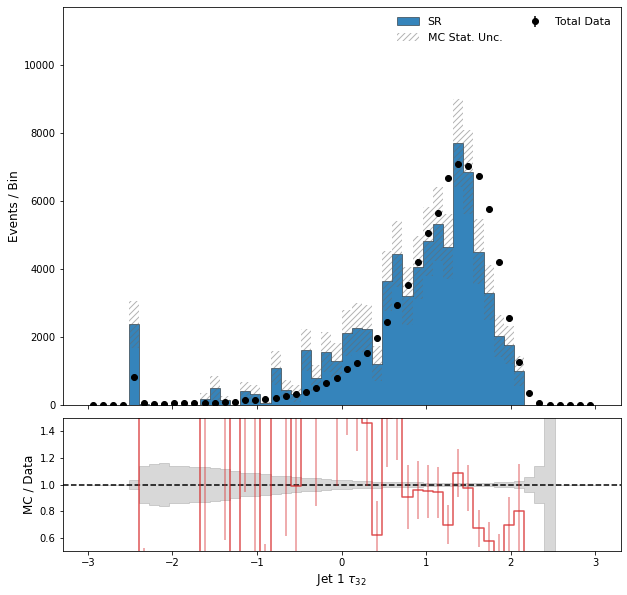

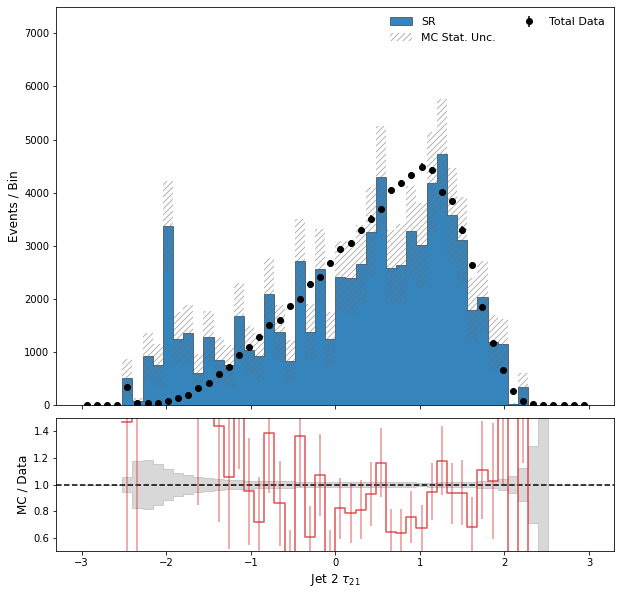

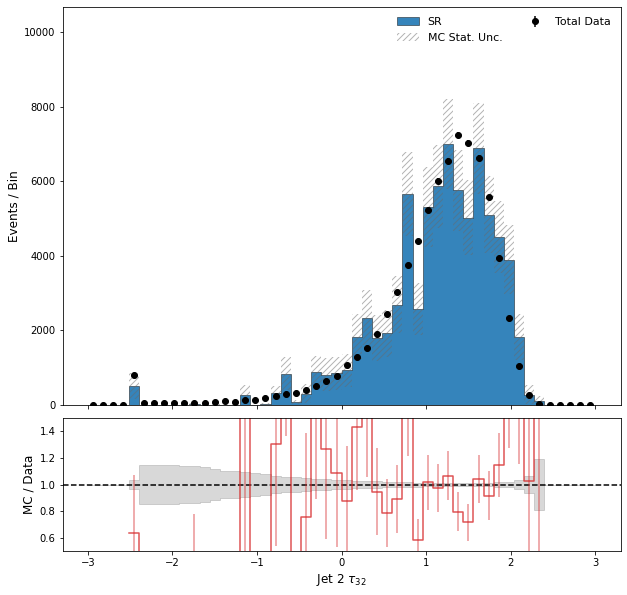

In [ ]:
print("\n--- EVALUATING REWEIGHT CLASSIFIER IN SIGNAL REGION ---")
mc_events_sr = pd.read_parquet(os.path.join(base_data_path, "Scaled_Regions_with_weights/MC_SR_test.parquet"))
data_events_sr = pd.read_parquet(os.path.join(base_data_path, "Scaled_Regions/Data_SR_test.parquet"))

model_path_region = os.path.join(model_path, "reweight_CR0L_FineTuned_3x500.pt")
NN_reweight = torch.load(model_path_region, weights_only=False)
NN_reweight.to(device)

input_data_sr = mc_events_sr[context_var + features].values
w_prob_sr = NN_reweight.evaluation(input_data_sr)

# Clip and Calculate
w_prob_sr = np.clip(w_prob_sr, 1e-7, 1.0 - 1e-7)
w_sr = (w_prob_sr / (1 - w_prob_sr)).flatten()
w_sr = regularize_weights(w_sr, sigma=3.0)

plot_stacked_crs_vs_data(
    mc_events_dict={"SR": mc_events_sr}, data_events_dict={"SR": data_events_sr},
    mc_weights_dict={"SR": w_sr}, regions=["SR"],
    feature_names=features, log_features=features_to_log,
    # save_dir=f"{eval_dir}/publication_plots_SR_combined",
)

### Generate 

In [ ]:
print("\n--- PREPARING DATA FOR GENERATIVE MODEL ---")
all_features, all_context = [], []
cr0l_features_train, cr0l_context_train = None, None

for region in CR_regions:
    # Generative model trains ONLY on Data
    df_data = pd.read_parquet(os.path.join(Data_train_outdir_CR, f"{region}_train.parquet"))
    
    data_feat = df_data[features].values
    data_cont = df_data[context_var].values
    
    all_features.append(data_feat)
    all_context.append(data_cont)

    if region == "CR0L":
        cr0l_features_train, cr0l_context_train = data_feat, data_cont
        
    del df_data
    gc.collect()

input_features_ALL = np.concatenate(all_features, axis=0)
input_context_ALL = np.concatenate(all_context, axis=0)
del all_features, all_context; gc.collect()

print(f"Phase 1 Combined Generative Training Data Shape: {input_features_ALL.shape}, Context Shape: {input_context_ALL.shape}")

with open(f"{config_path}/generate_physics.yml", 'r') as stream:
    params = yaml.safe_load(stream)

print("\n--- PHASE 1: Pre-training Normalizing Flow ---")
MAF = SimpleMAF(
    num_features=len(features), num_context=len(context_var), 
    device=device, num_layers=params["n_layers"], 
    num_hidden_features=params["n_hidden_features"], learning_rate=params["learning_rate"]
)

MAF.train(
    data=input_features_ALL, cond=input_context_ALL, 
    batch_size=params["batch_size"], n_epochs=params["n_epochs"], 
    outdir=model_path, save_model=True, model_name="generate_PreTrained_cpu"
)

print("\n--- PHASE 2: Fine-Tuning Normalizing Flow on CR0L ---")
fine_tune_lr = params["learning_rate"] / 10.0
for param_group in MAF.optimizer.param_groups:
    param_group['lr'] = fine_tune_lr

MAF.train(
    data=cr0l_features_train, cond=cr0l_context_train, 
    batch_size=params["batch_size"], n_epochs=params["n_epochs"] // 2, 
    outdir=model_path, save_model=True, model_name="generate_CR0L_FineTuned_cpu"
)   


--- PREPARING DATA FOR GENERATIVE MODEL ---
Phase 1 Combined Generative Training Data Shape: (39595626, 5), Context Shape: (39595626, 2)

--- PHASE 1: Pre-training Normalizing Flow ---


  5%|>         | 1/20 [3:19:42<63:14:31, 11982.69s/it]

In [7]:
print("\n--- EVALUATING GENERATE METHOD FOR CR0L ---")

# print("\n--- EVALUATING REWEIGHT CLASSIFIER IN CR0L ---")
MC_events_test, Data_events_test, weights_reweight = {}, {}, {}

# Load CR0L Test Events
df_mc_test = pd.read_parquet(os.path.join(MC_test_outdir_CR, "CR0L_test.parquet"))
df_data_test = pd.read_parquet(os.path.join(Data_test_outdir_CR, "CR0L_test.parquet"))

MC_events_test["CR0L"] = df_mc_test
Data_events_test["CR0L"] = df_data_test

# maf_model_path = os.path.join(model_path, "generate_CR0L_FineTuned.pt")
maf_model_path = os.path.join(model_path, "generate_PreTrained.pt")
MAF = torch.load(maf_model_path, map_location=device, weights_only=False)
MAF.flow.eval()

# Extract MC context to drive generation
mc_df = MC_events_test["CR0L"] # Loaded in Cell 5
mc_context = mc_df[context_var].values

# Batch generation to save VRAM
batch_size = 10000
generated_features_list = []

with torch.inference_mode():
    for i in tqdm(range(0, len(mc_context), batch_size), desc="Generation"):
        cond_batch = mc_context[i:i + batch_size]
        gen_feats = MAF.sample(num_samples=1, cond=cond_batch)
        generated_features_list.append(gen_feats)

synthetic_features = np.concatenate(generated_features_list, axis=0)

# Build Synthetic DataFrame
synthetic_df = pd.DataFrame(synthetic_features, columns=features)
for i, col in enumerate(context_var):
    synthetic_df[col] = mc_context[:, i]

# Load Reweight model for Likelihood Ratio
rw_model_path = os.path.join(model_path, "reweight_CR0L_FineTuned_3x500.pt")
NN_reweight = torch.load(rw_model_path, map_location=device, weights_only=False)
NN_reweight.to(device)
if hasattr(NN_reweight, 'model'): NN_reweight.model.eval() 

input_for_weights = synthetic_df[context_var + features].values
w_prob = NN_reweight.evaluation(input_for_weights)

# CRITICAL FIX: Clip Probs and Regularize Weights
w_prob = np.clip(w_prob, 1e-7, 1.0 - 1e-7)
w_cr = (w_prob / (1.0 - w_prob)).flatten()
w_cr_clipped = regularize_weights(w_cr, sigma=3.0)

weights_generate = {"CR0L": w_cr_clipped * (len(Data_events_test["CR0L"]) / len(MC_events_test["CR0L"]))}

plot_stacked_crs_vs_data(
    mc_events_dict={"CR0L": synthetic_df}, data_events_dict=Data_events_test,
    mc_weights_dict=weights_generate, regions=["CR0L"],
    feature_names=features, log_features=features_to_log,
    # save_dir=f"{eval_dir}/publication_plots_stacked_generate",
)


--- EVALUATING GENERATE METHOD FOR CR0L ---


Generation:   0%|          | 0/108 [00:00<?, ?it/s]


RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cpu and cuda:0! (when checking argument for argument mat1 in method wrapper_CUDA_addmm)